In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [8]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [9]:
#Removing unnecessary columns
df = df.drop(['area_type','availability','society','balcony'], axis=1)

#Check missing values
df.isnull().sum()

#Drop missing values
df = df.dropna()

In [10]:
#getting no. of bedrooms from size column
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df.drop('size', axis=1, inplace=True)

In [11]:
#getting values in sq feet
def convert_sqft(x):
    try:
        if '-' in str(x):
            a = x.split('-')
            return (float(a[0])+float(a[1]))/2
        return float(x)
    except:
        return None

In [12]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [13]:
#getting price per sq foot
df['price_per_sqft'] = (df['price']*100000)/df['total_sqft']

In [14]:
location_count = df.location.value_counts()

location_count_less_10 = location_count[location_count<=10]

df.location = df.location.apply(lambda x:'Other' if x in location_count_less_10 else x)

In [15]:
df = pd.get_dummies(df, columns=['location'])

In [16]:
df = df[df.total_sqft/df.bhk>300]

In [17]:
mean = df.price_per_sqft.mean()
std = df.price_per_sqft.std()

df = df[(df.price_per_sqft>mean-std) &
        (df.price_per_sqft<mean+std)]

In [18]:
df.drop('price_per_sqft', axis=1, inplace=True)

In [19]:
plt.style.use("ggplot")

In [20]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 11167
Columns: 246


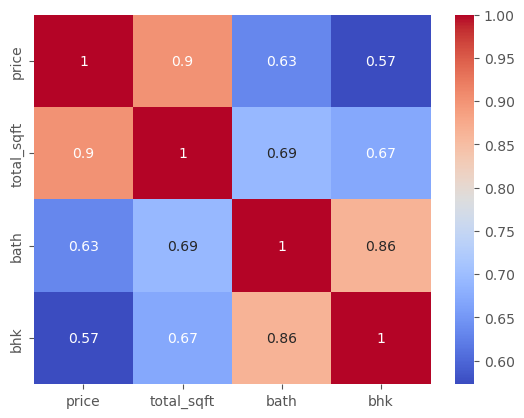

In [21]:
cols = ['price', 'total_sqft', 'bath', 'bhk']

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

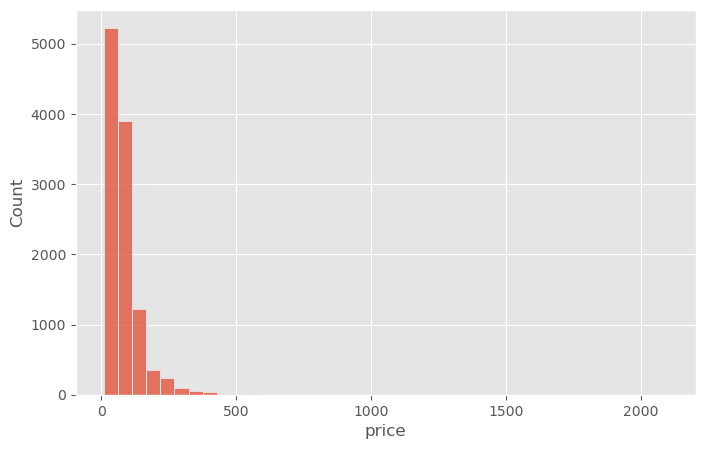

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40)
plt.show()

<Axes: xlabel='bath', ylabel='price'>

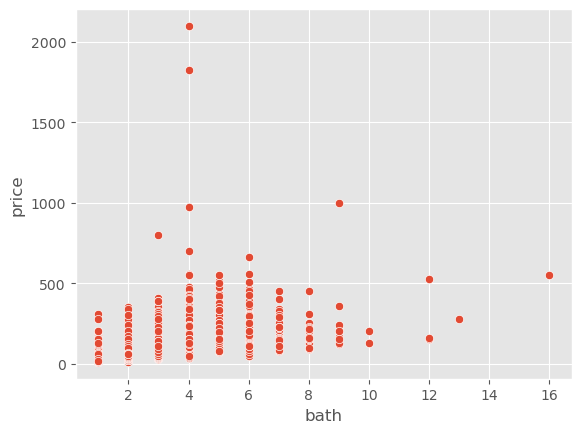

In [23]:
sns.scatterplot(x='bath', y='price', data=df)

<Axes: xlabel='total_sqft', ylabel='price'>

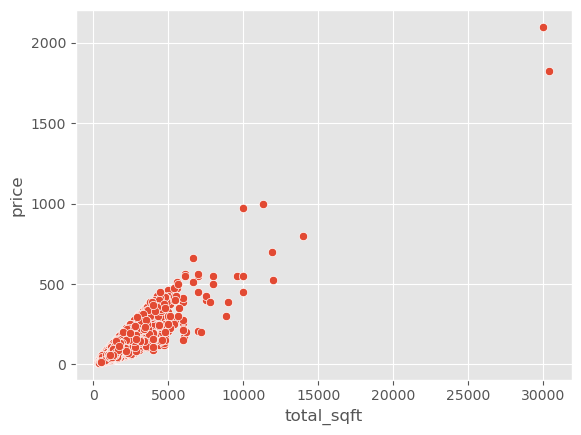

In [24]:
sns.scatterplot(x='total_sqft', y='price', data=df)

<Axes: xlabel='bhk', ylabel='count'>

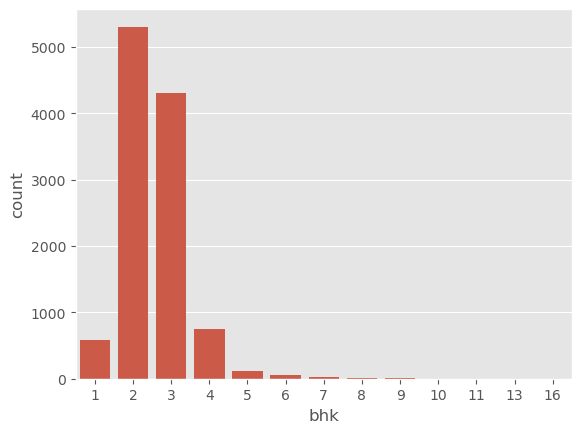

In [25]:
sns.countplot(x='bhk', data=df)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [27]:
X = df.drop('price', axis=1)

y = df['price']

In [28]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [44]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

In [31]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [45]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

In [43]:
def evaluate(y_test,pred):
    print("MAE :",mean_absolute_error(y_test,pred))
    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))
    print("R2 :",r2_score(y_test,pred))

In [34]:
evaluate(y_test,pred_lr)
evaluate(y_test,pred_rf)
evaluate(y_test,pred_gb)

MAE : 17.000146104776004
RMSE : 26.82094693175257
R2 : 0.8591728216669408
MAE : 15.10924754688461
RMSE : 27.032618516547878
R2 : 0.8569412271430481
MAE : 17.150080904930682
RMSE : 26.236401753581898
R2 : 0.8652444040278715


In [35]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_gb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_gb))
    ],
    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb)
    ]
})

print(results)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  17.000146  26.820947  0.859173
1      Random Forest  15.109248  27.032619  0.856941
2  Gradient Boosting  17.150081  26.236402  0.865244


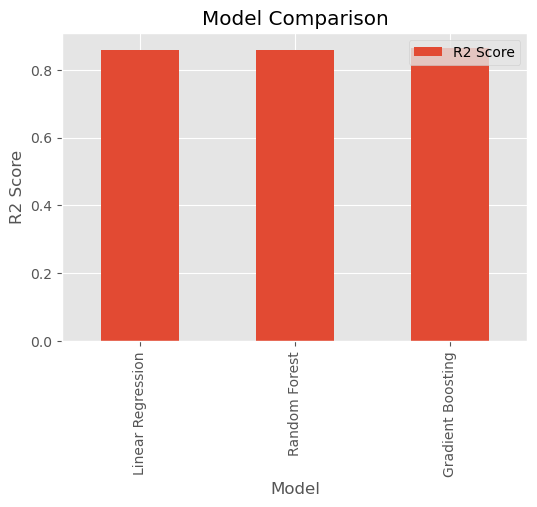

In [36]:
results.plot(x='Model', y='R2 Score', kind='bar', figsize=(6,4))
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

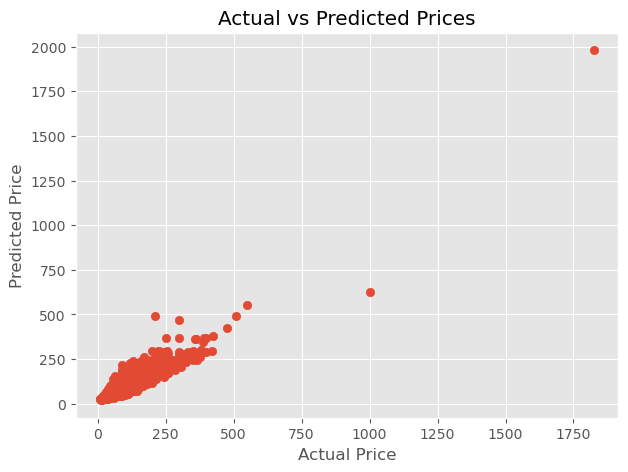

In [37]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_gb)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

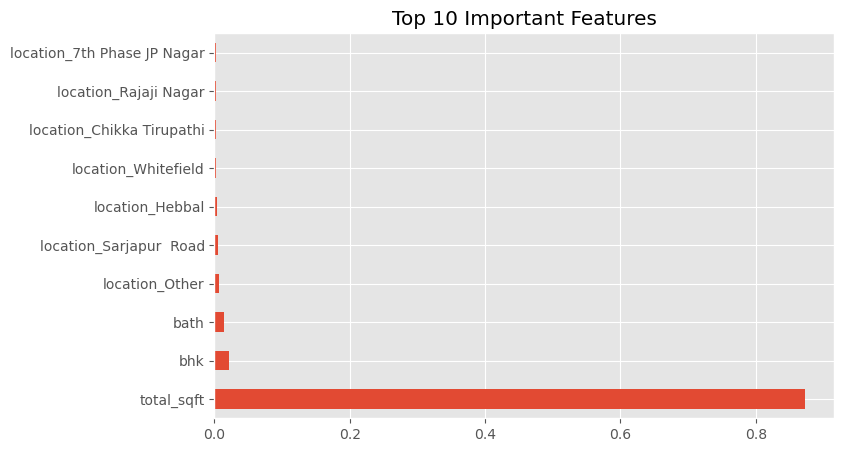

In [38]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Important Features")
plt.show()

In [47]:
import pickle
pickle.dump(gb, open("real_estate_price_model.pkl", "wb"))